# Parte 2: Modelo Predictivo de Churn
## Data Scientist Challenge – Entel

**Restricciones de negocio:**
- Solo se pueden contactar **2.000 clientes/mes**
- Costo por contacto: **$1.000 CLP**
- Valor recuperado por cliente retenido: **$30.000 CLP**
- Tasa de éxito de retención: **10%** sobre los churners contactados

**Lógica de ganancia:**
`Ganancia = (True Positives × 0.10 × $30.000) – (2.000 × $1.000)`

---

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

SEED = 42
np.random.seed(SEED)

# Constantes de negocio
BUDGET_CONTACTS   = 2_000       # clientes contactables por mes
COST_PER_CONTACT  = 1_000       # CLP por contacto
VALUE_RETAINED    = 30_000      # CLP por cliente retenido
RETENTION_RATE    = 0.10        # 10% de éxito solo sobre churners reales

DATA_PATH = '../documentos/dataset_prueba.csv'

In [32]:
df = pd.read_csv(DATA_PATH)
df['last_date_of_month'] = pd.to_datetime(df['last_date_of_month'])

def crear_features(data):
    d = data.copy()
    total_vol = d['vol_2g_mb'].fillna(0) + d['vol_3g_mb'].fillna(0)
    d['ratio_3g_vs_total']   = np.where(total_vol > 0, d['vol_3g_mb'].fillna(0) / total_vol, 0)
    d['total_voz_mou']       = d['total_og_mou'].fillna(0) + d['total_ic_mou'].fillna(0)
    roam_total = d['roam_ic_mou'].fillna(0) + d['roam_og_mou'].fillna(0)
    d['ratio_roam']          = np.where(d['total_voz_mou'] > 0, roam_total / d['total_voz_mou'], 0)
    d['hizo_recarga_datos']  = (d['total_rech_data'].fillna(0) > 0).astype(int)
    arpu_mean                = d['arpu'].mean()
    d['arpu_vs_media']       = d['arpu'] - arpu_mean
    d['avg_rech_amt']        = np.where(d['total_rech_num'] > 0, d['total_rech_amt'] / d['total_rech_num'], 0)
    d['es_usuario_datos']    = (total_vol > 0).astype(int)
    d['balance_og_ic']       = d['total_og_mou'].fillna(0) - d['total_ic_mou'].fillna(0)
    d['inactivo_total']      = (
        (d['total_og_mou'].fillna(0) == 0) &
        (d['total_ic_mou'].fillna(0) == 0) &
        (d['total_rech_amt'].fillna(0) == 0)
    ).astype(int)
    return d

df = crear_features(df)

train_dates = pd.to_datetime(['2014-06-30', '2014-07-31'])
test_date   = pd.to_datetime('2014-08-31')

df_train = df[df['last_date_of_month'].isin(train_dates)].copy()
df_test  = df[df['last_date_of_month'] == test_date].copy()

print(f'Train: {len(df_train):,} | Test: {len(df_test):,}')
print(f'Churn en train: {df_train["churn"].mean()*100:.2f}%  |  Churn en test: {df_test["churn"].mean()*100:.2f}%')

Train: 199,397 | Test: 98,899
Churn en train: 1.28%  |  Churn en test: 1.90%


## 1. Preparación de features para modelado

Se excluyen columnas no predictivas (IDs, fechas, target) y se realiza imputación con 0 para variables de uso.

In [33]:
# Columnas a excluir del modelo
EXCLUDE_COLS = [
    'mobile_number', 'last_date_of_month', 'churn',
    'date_of_last_rech', 'date_of_last_rech_data',
    'arpu_segment'  # Variable categórica derivada — se podría one-hot, pero se omite para simplicidad
]

# Seleccionar solo columnas numéricas
feature_cols = [
    c for c in df_train.select_dtypes(include=np.number).columns
    if c not in EXCLUDE_COLS
]

print(f'Total de features: {len(feature_cols)}')
print(feature_cols)

X_train = df_train[feature_cols].copy()
y_train = df_train['churn'].values

X_test  = df_test[feature_cols].copy()
y_test  = df_test['churn'].values

# Imputar nulos con 0 (uso ausente = no uso ese mes)
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

print(f'\nNulos restantes en X_train: {X_train.isnull().sum().sum()}')
print(f'Nulos restantes en X_test:  {X_test.isnull().sum().sum()}')

Total de features: 60
['arpu', 'onnet_mou', 'offnet_mou', 'roam_ic_mou', 'roam_og_mou', 'loc_og_t2t_mou', 'loc_og_t2m_mou', 'loc_og_t2f_mou', 'loc_og_t2c_mou', 'loc_og_mou', 'std_og_t2t_mou', 'std_og_t2m_mou', 'std_og_t2f_mou', 'std_og_t2c_mou', 'std_og_mou', 'isd_og_mou', 'spl_og_mou', 'og_others', 'total_og_mou', 'loc_ic_t2t_mou', 'loc_ic_t2m_mou', 'loc_ic_t2f_mou', 'loc_ic_mou', 'std_ic_t2t_mou', 'std_ic_t2m_mou', 'std_ic_t2f_mou', 'std_ic_t2o_mou', 'std_ic_mou', 'total_ic_mou', 'spl_ic_mou', 'isd_ic_mou', 'ic_others', 'total_rech_num', 'total_rech_amt', 'max_rech_amt', 'last_day_rch_amt', 'total_rech_data', 'max_rech_data', 'count_rech_2g', 'count_rech_3g', 'av_rech_amt_data', 'vol_2g_mb', 'vol_3g_mb', 'arpu_3g', 'arpu_2g', 'night_pck_user', 'monthly_2g', 'sachet_2g', 'monthly_3g', 'sachet_3g', 'fb_user', 'ratio_3g_vs_total', 'total_voz_mou', 'ratio_roam', 'hizo_recarga_datos', 'arpu_vs_media', 'avg_rech_amt', 'es_usuario_datos', 'balance_og_ic', 'inactivo_total']

Nulos restantes 

## 2. Función de métricas de negocio

Dado que el objetivo final es **maximizar la ganancia** dentro del presupuesto de 2.000 contactos, definimos una función que calcula el resultado económico dado un set de predicciones.

In [34]:
def ganancia_negocio(y_true, y_proba, top_n=BUDGET_CONTACTS,
                     cost=COST_PER_CONTACT, value=VALUE_RETAINED,
                     retention_rate=RETENTION_RATE):
    """
    Calcula la ganancia neta seleccionando los top_n clientes
    con mayor probabilidad de churn.

    Ganancia = TP_top_n * retention_rate * value - top_n * cost
    """
    df_eval = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df_eval = df_eval.sort_values('y_proba', ascending=False).head(top_n)

    tp = df_eval['y_true'].sum()   # Verdaderos churners en el top N
    fp = top_n - tp                # No churners contactados (costo sin retorno)

    ingresos = tp * retention_rate * value
    costos   = top_n * cost
    ganancia = ingresos - costos

    return {
        'top_n': top_n,
        'true_positives': tp,
        'false_positives': fp,
        'precision_top_n': tp / top_n,
        'ingresos_CLP': ingresos,
        'costos_CLP': costos,
        'ganancia_neta_CLP': ganancia,
        'ROI': (ganancia / costos) * 100 if costos > 0 else 0
    }

def ganancia_random_baseline(y_true, top_n=BUDGET_CONTACTS,
                              cost=COST_PER_CONTACT, value=VALUE_RETAINED,
                              retention_rate=RETENTION_RATE):
    """Ganancia esperada si se seleccionan clientes aleatoriamente."""
    churn_rate = y_true.mean()
    tp_esperados = top_n * churn_rate
    ingresos = tp_esperados * retention_rate * value
    costos   = top_n * cost
    return {
        'tp_esperados': tp_esperados,
        'ingresos_CLP': ingresos,
        'costos_CLP': costos,
        'ganancia_neta_CLP': ingresos - costos
    }

baseline = ganancia_random_baseline(y_test)
print('=== Baseline aleatorio (test) ===')
for k, v in baseline.items():
    print(f'  {k}: {v:,.0f}')

=== Baseline aleatorio (test) ===
  tp_esperados: 38
  ingresos_CLP: 114,177
  costos_CLP: 2,000,000
  ganancia_neta_CLP: -1,885,823


## 3. Modelamiento

### Elección de modelos

Se entrenan 3 modelos con distintos trade-offs:

| Modelo | Ventajas | Desventajas |
|--------|----------|-------------|
| **Regresión Logística** | Interpretable, rápido, buen baseline | Puede no capturar no-linealidades |
| **Random Forest** | Robusto, maneja no-linealidades, importancia de features | Lento en datasets grandes |
| **LightGBM** | Muy eficiente, alta performance en datos tabulares, maneja desbalance | Menos interpretable |

**Decisión principal:** Dado el desbalance de clases (churn es minoría), se optimizan los modelos por **AUC-ROC** y se evalúan por **ganancia de negocio** en el top 2.000.

In [35]:
results = {}

# ============================================================
# MODELO 1: Regresión Logística (baseline interpretable)
# ============================================================
print('Entrenando Regresión Logística...')

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',   # Maneja desbalance de clases
        max_iter=500,
        random_state=SEED,
        C=0.1                      # Regularización para evitar overfitting
    ))
])

lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]

results['Logistic Regression'] = {
    'proba': lr_proba,
    'auc': roc_auc_score(y_test, lr_proba),
    'ap': average_precision_score(y_test, lr_proba),
    'negocio': ganancia_negocio(y_test, lr_proba)
}
print(f'  AUC-ROC: {results["Logistic Regression"]["auc"]:.4f}')
print(f'  Ganancia neta: ${results["Logistic Regression"]["negocio"]["ganancia_neta_CLP"]:,.0f} CLP')

Entrenando Regresión Logística...
  AUC-ROC: 0.8661
  Ganancia neta: $-821,000 CLP


In [36]:
# ============================================================
# MODELO 2: LightGBM (modelo principal — mejor balance performance/velocidad)
# ============================================================

# Calcular peso de clases para manejar desbalance
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f'  scale_pos_weight: {scale_pos_weight:.2f} (ratio no-churn / churn)')

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=50,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

results['LightGBM'] = {
    'proba': lgb_proba,
    'auc': roc_auc_score(y_test, lgb_proba),
    'ap': average_precision_score(y_test, lgb_proba),
    'negocio': ganancia_negocio(y_test, lgb_proba)
}
print(f'  AUC-ROC: {results["LightGBM"]["auc"]:.4f}')
print(f'  Ganancia neta: ${results["LightGBM"]["negocio"]["ganancia_neta_CLP"]:,.0f} CLP')

  scale_pos_weight: 77.16 (ratio no-churn / churn)
  AUC-ROC: 0.8526
  Ganancia neta: $-380,000 CLP


In [37]:
# ============================================================
# MODELO 3: Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

results['Random Forest'] = {
    'proba': rf_proba,
    'auc': roc_auc_score(y_test, rf_proba),
    'ap': average_precision_score(y_test, rf_proba),
    'negocio': ganancia_negocio(y_test, rf_proba)
}
print(f'  AUC-ROC: {results["Random Forest"]["auc"]:.4f}')
print(f'  Ganancia neta: ${results["Random Forest"]["negocio"]["ganancia_neta_CLP"]:,.0f} CLP')

  AUC-ROC: 0.8832
  Ganancia neta: $157,000 CLP


---
## 3.5 Manejo del desbalance: SMOTETomek vs `scale_pos_weight`

Se evalúa si el rebalanceo a nivel de datos (**SMOTETomek**) mejora el F1 de Churn
respecto a la penalización implícita de costos (`scale_pos_weight`) del modelo base.

| Estrategia | Mecanismo | Ventaja |
|---|---|---|
| `scale_pos_weight` | Penaliza más los falsos negativos en entrenamiento | No modifica datos; rápido de entrenar |
| **SMOTETomek** | SMOTE (síntesis de muestras minoritarias) + Tomek Links (limpieza de frontera) | Frontera de decisión más nítida; puede mejorar F1 y KS |

**Hipótesis:** SMOTETomek crea muestras sintéticas en la región de decisión y elimina los pares ambiguos, forzando al modelo a aprender una separación más precisa.

In [38]:
from imblearn.combine import SMOTETomek

print('Aplicando SMOTETomek al set de entrenamiento...')
print(f'  Original — No-Churn: {(y_train==0).sum():,} | Churn: {(y_train==1).sum():,}')

smt = SMOTETomek(random_state=SEED)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

print(f'  Post-SMOTETomek — No-Churn: {(y_train_smt==0).sum():,} | Churn: {(y_train_smt==1).sum():,}')
print(f'  Tamaño total: {len(X_train):,} → {len(X_train_smt):,} muestras')

Aplicando SMOTETomek al set de entrenamiento...
  Original — No-Churn: 196,846 | Churn: 2,551
  Post-SMOTETomek — No-Churn: 196,693 | Churn: 196,693
  Tamaño total: 199,397 → 393,386 muestras


In [39]:
print('Entrenando LightGBM + SMOTETomek (sin scale_pos_weight)...')

lgb_smt = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=50,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
    # Sin scale_pos_weight: el balance lo resuelve SMOTETomek
)

lgb_smt.fit(
    X_train_smt, y_train_smt,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

lgb_smt_proba = lgb_smt.predict_proba(X_test)[:, 1]

results['LightGBM + SMOTETomek'] = {
    'proba': lgb_smt_proba,
    'auc':   roc_auc_score(y_test, lgb_smt_proba),
    'ap':    average_precision_score(y_test, lgb_smt_proba),
    'negocio': ganancia_negocio(y_test, lgb_smt_proba)
}

print(f'  AUC-ROC:       {results["LightGBM + SMOTETomek"]["auc"]:.4f}')
print(f'  Ganancia neta: ${results["LightGBM + SMOTETomek"]["negocio"]["ganancia_neta_CLP"]:,.0f} CLP')

Entrenando LightGBM + SMOTETomek (sin scale_pos_weight)...
[100]	valid_0's binary_logloss: 0.236554
[200]	valid_0's binary_logloss: 0.190091
[300]	valid_0's binary_logloss: 0.170702
[400]	valid_0's binary_logloss: 0.158235
[500]	valid_0's binary_logloss: 0.150398
  AUC-ROC:       0.8843
  Ganancia neta: $-77,000 CLP


In [40]:
def ks_statistic(y_true, y_proba):
    """
    KS Statistic: máxima separación entre las CDFs acumuladas de churners y no-churners.
    KS > 0.40 se considera bueno en modelos de crédito/churn.
    Retorna: (ks_max, threshold_óptimo, DataFrame con curvas)
    """
    df_ks = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df_ks = df_ks.sort_values('y_proba').reset_index(drop=True)
    n_pos = (y_true == 1).sum()
    n_neg = (y_true == 0).sum()
    df_ks['cum_churn']    = (df_ks['y_true'] == 1).cumsum() / n_pos
    df_ks['cum_no_churn'] = (df_ks['y_true'] == 0).cumsum() / n_neg
    df_ks['ks']           = (df_ks['cum_churn'] - df_ks['cum_no_churn']).abs()
    ks_max    = df_ks['ks'].max()
    ks_thresh = df_ks.loc[df_ks['ks'].idxmax(), 'y_proba']
    return ks_max, ks_thresh, df_ks


def best_f1_score(y_true, y_proba):
    """F1 máximo barriendo todos los thresholds de la curva PR."""
    prec, rec, threshs = precision_recall_curve(y_true, y_proba)
    f1  = 2 * prec * rec / (prec + rec + 1e-10)
    idx = np.argmax(f1)
    thresh = threshs[idx] if idx < len(threshs) else threshs[-1]
    return float(f1[idx]), float(thresh)

## 4. Comparación de modelos

In [41]:
# Calcular KS Statistic y F1 óptimo para todos los modelos
for name, r in results.items():
    ks, ks_thresh, _  = ks_statistic(y_test, r['proba'])
    f1, f1_thresh     = best_f1_score(y_test, r['proba'])
    r['ks']             = ks
    r['ks_threshold']   = ks_thresh
    r['best_f1']        = f1
    r['best_f1_thresh'] = f1_thresh

print('='*95)
print(f'{"Modelo":<28} {"AUC-ROC":>8} {"AP":>8} {"KS Stat":>8} {"F1-Churn":>9} {"Prec@2k":>8} {"Ganancia CLP":>14}')
print('-'*95)
for name, r in results.items():
    g = r['negocio']
    print(f'{name:<28} {r["auc"]:>8.4f} {r["ap"]:>8.4f} '
          f'{r["ks"]:>8.4f} {r["best_f1"]:>9.4f} '
          f'{g["precision_top_n"]:>8.3f} {g["ganancia_neta_CLP"]:>14,.0f}')
print(f'{"Baseline aleatorio":<28} {"-":>8} {"-":>8} {"-":>8} {"-":>9} '
      f'{y_test.mean():>8.3f} {baseline["ganancia_neta_CLP"]:>14,.0f}')
print('='*95)

Modelo                        AUC-ROC       AP  KS Stat  F1-Churn  Prec@2k   Ganancia CLP
-----------------------------------------------------------------------------------------------
Logistic Regression            0.8661   0.1596   0.6025    0.3216    0.197       -821,000
LightGBM                       0.8526   0.1970   0.6135    0.3778    0.270       -380,000
Random Forest                  0.8832   0.2873   0.6631    0.4152    0.359        157,000
LightGBM + SMOTETomek          0.8843   0.2791   0.6447    0.4121    0.321        -77,000
Baseline aleatorio                  -        -        -         -    0.019     -1,885,823


### Interpretación de métricas de discriminación

| Métrica | Qué mide | Umbral "bueno" en churn |
|---|---|---|
| **AUC-ROC** | Separación global churners vs. no-churners a todos los thresholds | > 0.75 |
| **KS Statistic** | Máxima diferencia entre las CDFs acumuladas de ambas clases | > 0.40 |
| **F1-Churn** | Balance precision/recall en el threshold óptimo para la clase churn | > 0.40 |

El **KS Statistic** es especialmente útil en scoring de riesgo: indica en qué score se produce la mayor discriminación y sirve para definir el punto de corte operativo de la campaña.

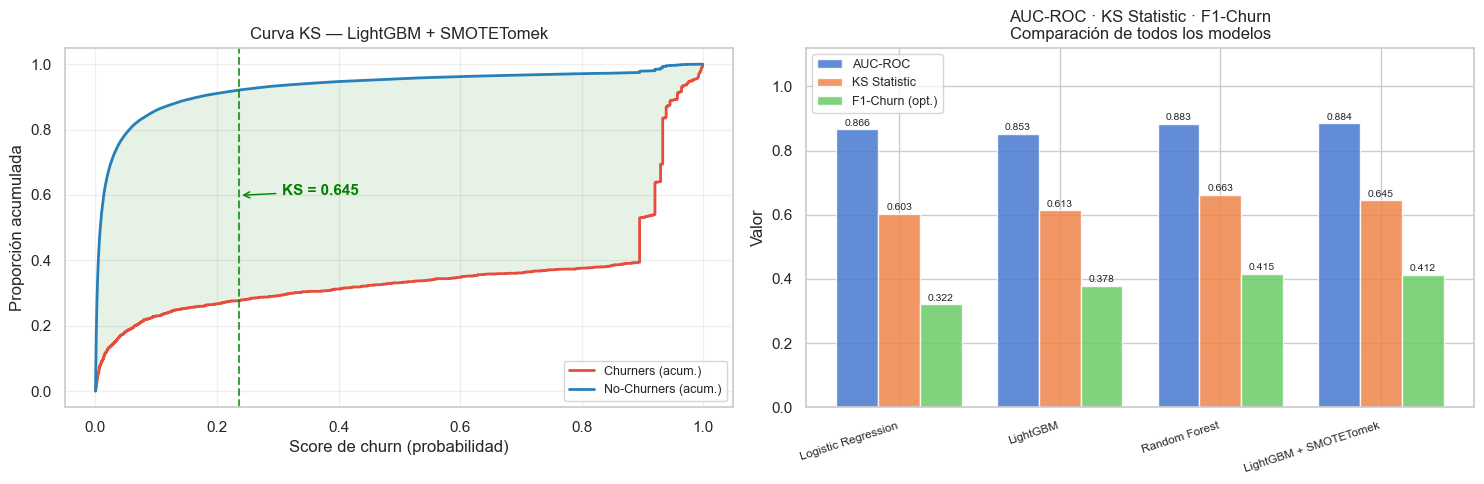

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Plot 1: Curva KS del mejor modelo (mayor AUC-ROC) ──────────────────────
best_name = max(results, key=lambda k: results[k]['auc'])
_, _, df_ks_best = ks_statistic(y_test, results[best_name]['proba'])
best_ks  = results[best_name]['ks']
ks_x     = df_ks_best.loc[df_ks_best['ks'].idxmax(), 'y_proba']
ks_y_pos = df_ks_best.loc[df_ks_best['ks'].idxmax(), 'cum_churn']
ks_y_neg = df_ks_best.loc[df_ks_best['ks'].idxmax(), 'cum_no_churn']

axes[0].plot(df_ks_best['y_proba'], df_ks_best['cum_churn'],
             label='Churners (acum.)',    color='#e74c3c', linewidth=2)
axes[0].plot(df_ks_best['y_proba'], df_ks_best['cum_no_churn'],
             label='No-Churners (acum.)', color='#2980b9', linewidth=2)
axes[0].fill_between(df_ks_best['y_proba'],
                     df_ks_best['cum_churn'], df_ks_best['cum_no_churn'],
                     alpha=0.10, color='green')
axes[0].axvline(ks_x, color='green', linestyle='--', alpha=0.75)
axes[0].annotate(
    f'KS = {best_ks:.3f}',
    xy=(ks_x, (ks_y_pos + ks_y_neg) / 2),
    xytext=(ks_x + 0.07, (ks_y_pos + ks_y_neg) / 2),
    arrowprops=dict(arrowstyle='->', color='green'),
    fontsize=11, color='green', fontweight='bold'
)
axes[0].set_title(f'Curva KS — {best_name}', fontsize=12)
axes[0].set_xlabel('Score de churn (probabilidad)')
axes[0].set_ylabel('Proporción acumulada')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Comparación AUC-ROC · KS · F1 por modelo ──────────────────────
model_names = list(results.keys())
x      = np.arange(len(model_names))
width  = 0.26
aucs   = [results[m]['auc']     for m in model_names]
ks_v   = [results[m]['ks']      for m in model_names]
f1_v   = [results[m]['best_f1'] for m in model_names]

b1 = axes[1].bar(x - width, aucs,  width, label='AUC-ROC',        color='#4878d0', alpha=0.85)
b2 = axes[1].bar(x,         ks_v,  width, label='KS Statistic',    color='#ee854a', alpha=0.85)
b3 = axes[1].bar(x + width, f1_v,  width, label='F1-Churn (opt.)', color='#6acc65', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.005,
                     f'{bar.get_height():.3f}',
                     ha='center', va='bottom', fontsize=7.5)

axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=18, ha='right', fontsize=8.5)
axes[1].set_ylabel('Valor')
axes[1].set_title('AUC-ROC · KS Statistic · F1-Churn\nComparación de todos los modelos')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.12)

plt.tight_layout()
plt.savefig('../notebooks/fig_11_ks_auc_f1_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

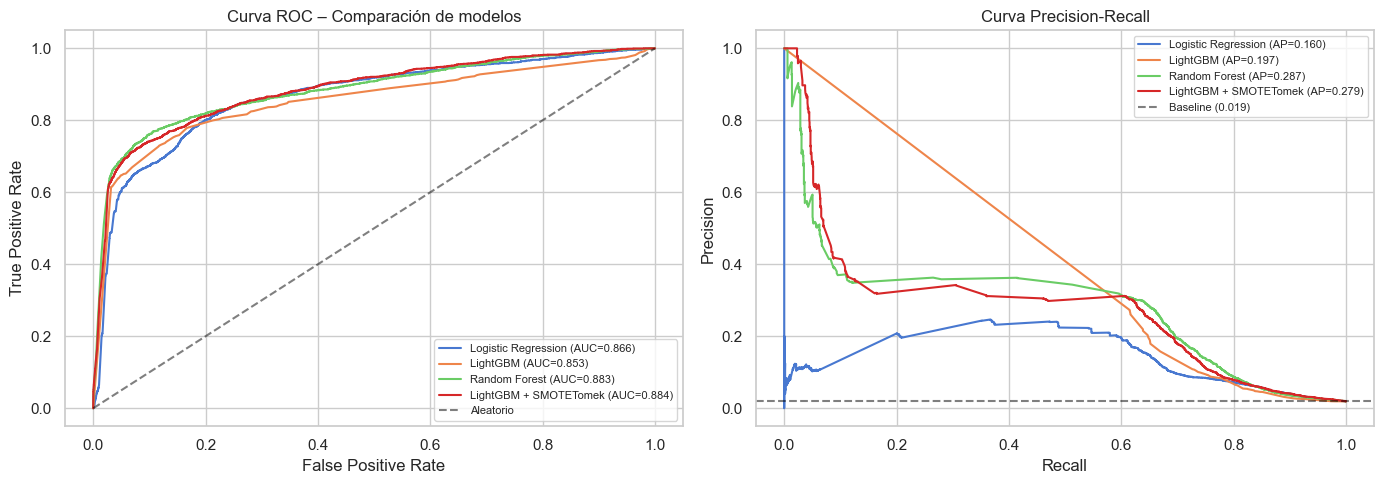

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {
    'Logistic Regression':    '#4878d0',
    'LightGBM':               '#ee854a',
    'Random Forest':          '#6acc65',
    'LightGBM + SMOTETomek':  '#d62728'
}

# Curvas ROC
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})", color=colors_map[name])
axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Aleatorio')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC – Comparación de modelos')
axes[0].legend(fontsize=8)

# Curvas Precision-Recall
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r['proba'])
    axes[1].plot(rec, prec, label=f"{name} (AP={r['ap']:.3f})", color=colors_map[name])
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../notebooks/fig_07_roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Importancia de features (LightGBM)



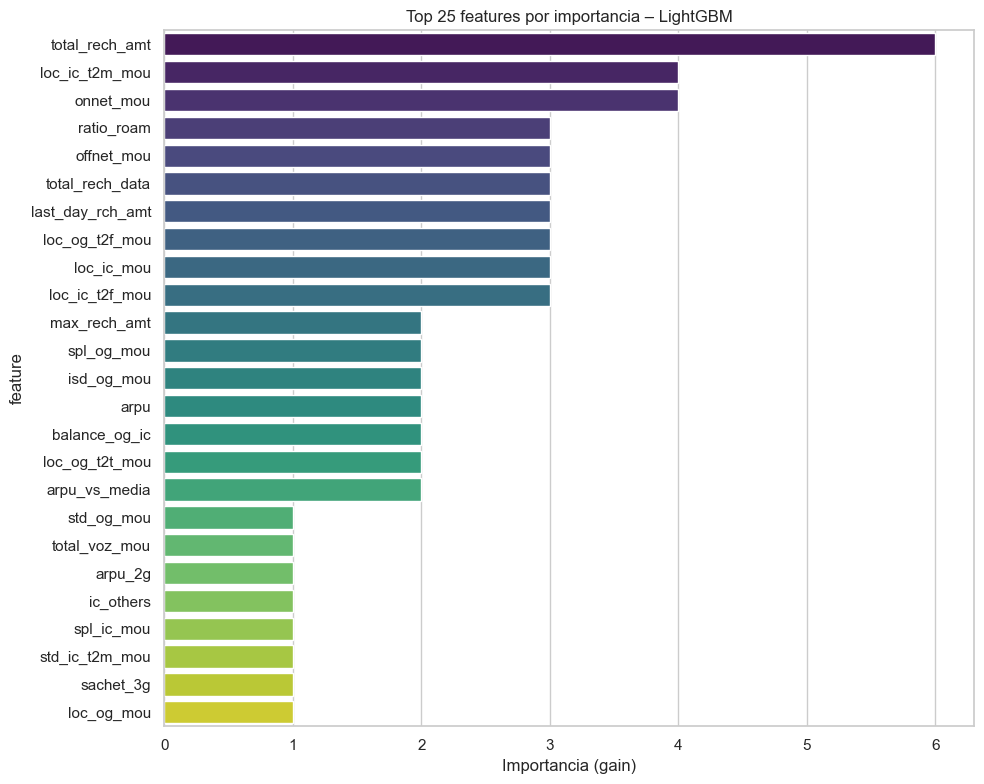

Top 10 features más importantes:
         feature  importance
  total_rech_amt           6
  loc_ic_t2m_mou           4
       onnet_mou           4
      ratio_roam           3
      offnet_mou           3
 total_rech_data           3
last_day_rch_amt           3
  loc_og_t2f_mou           3
      loc_ic_mou           3
  loc_ic_t2f_mou           3


In [44]:
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_imp.head(25), x='importance', y='feature', ax=ax, palette='viridis')
ax.set_title('Top 25 features por importancia – LightGBM')
ax.set_xlabel('Importancia (gain)')
plt.tight_layout()
plt.show()

print('Top 10 features más importantes:')
print(feat_imp.head(10).to_string(index=False))

---
## 6. Priorización de 2.000 clientes

### Estrategia de scoring y ranking

**Decisión:** Se usa la **probabilidad de churn** del modelo LightGBM como score de riesgo, y se seleccionan los **top 2.000** clientes con mayor probabilidad de churn del mes de test (agosto 2014).

**Justificación:**
- Maximizar True Positives (churners reales) en el top 2.000 maximiza la ganancia.
- Ordenar por probabilidad de churn es equivalente a ordenar por valor esperado de retención (dado que el valor por cliente es constante en este modelo).
- Si hubiera datos de ARPU por cliente (valor diferenciado), se podría ponderar por `P(churn) × ARPU`, priorizando churners de alto valor.

In [45]:
# Construir tabla de scoring para el set de test
df_scoring = df_test[['mobile_number', 'arpu', 'churn']].copy()
df_scoring['churn_proba']     = lgb_proba
df_scoring['valor_esperado']  = df_scoring['churn_proba'] * RETENTION_RATE * VALUE_RETAINED
df_scoring = df_scoring.sort_values('churn_proba', ascending=False).reset_index(drop=True)
df_scoring['rank'] = df_scoring.index + 1

# Top 2000 seleccionados
top2000 = df_scoring.head(BUDGET_CONTACTS)

print(f'=== TOP {BUDGET_CONTACTS} CLIENTES SELECCIONADOS ===')
print(f'Churners reales identificados: {top2000["churn"].sum():,}')
print(f'Precision@2000:               {top2000["churn"].mean()*100:.1f}%')
print(f'Clientes retenidos esperados: {top2000["churn"].sum() * RETENTION_RATE:.1f}')
print()

g = ganancia_negocio(y_test, lgb_proba)
print(f'Ingresos esperados:   ${g["ingresos_CLP"]:>12,.0f} CLP')
print(f'Costos de campaña:    ${g["costos_CLP"]:>12,.0f} CLP')
print(f'Ganancia neta:        ${g["ganancia_neta_CLP"]:>12,.0f} CLP')
print(f'ROI:                  {g["ROI"]:.1f}%')

=== TOP 2000 CLIENTES SELECCIONADOS ===
Churners reales identificados: 540
Precision@2000:               27.0%
Clientes retenidos esperados: 54.0

Ingresos esperados:   $   1,620,000 CLP
Costos de campaña:    $   2,000,000 CLP
Ganancia neta:        $    -380,000 CLP
ROI:                  -19.0%


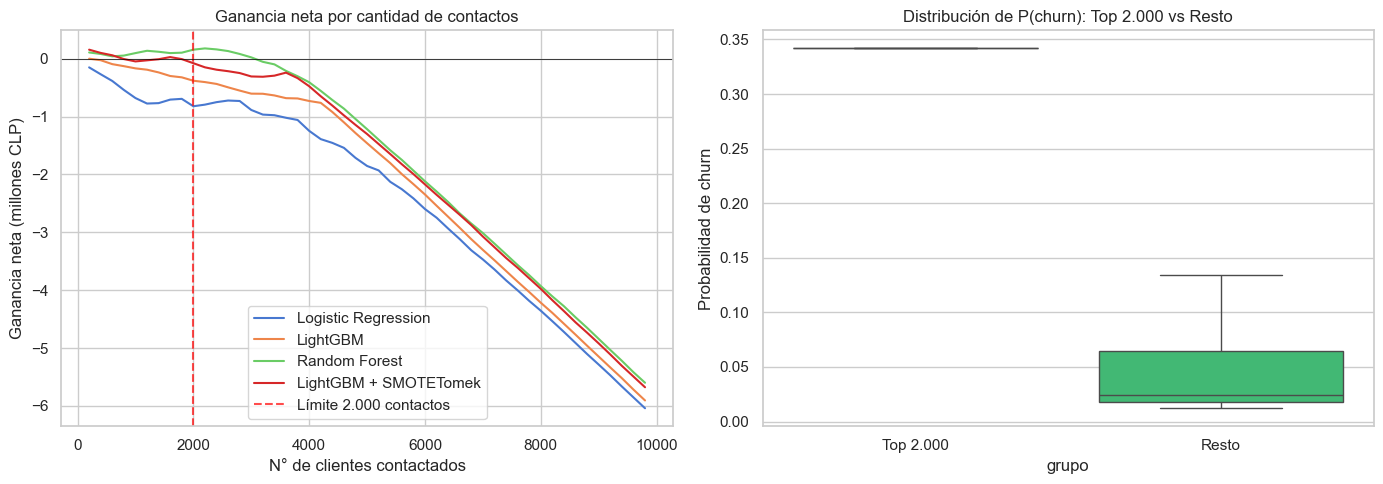

In [46]:
# Curva de ganancia acumulada según cuántos clientes se contactan
def calcular_ganancia_por_n(y_true, y_proba, max_n=10000, step=200):
    df_eval = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df_eval = df_eval.sort_values('y_proba', ascending=False).reset_index(drop=True)

    ns = list(range(step, min(max_n, len(df_eval)), step))
    ganancias = []
    for n in ns:
        tp = df_eval.head(n)['y_true'].sum()
        g  = tp * RETENTION_RATE * VALUE_RETAINED - n * COST_PER_CONTACT
        ganancias.append(g)
    return ns, ganancias

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in results.items():
    ns, gs = calcular_ganancia_por_n(y_test, r['proba'])
    axes[0].plot(ns, [g/1e6 for g in gs], label=name, color=colors_map[name])

axes[0].axvline(BUDGET_CONTACTS, color='red', linestyle='--', alpha=0.7, label='Límite 2.000 contactos')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('N° de clientes contactados')
axes[0].set_ylabel('Ganancia neta (millones CLP)')
axes[0].set_title('Ganancia neta por cantidad de contactos')
axes[0].legend()

# Distribución de probabilidad de churn: top 2000 vs resto
df_scoring['grupo'] = np.where(df_scoring['rank'] <= BUDGET_CONTACTS, 'Top 2.000', 'Resto')
sns.boxplot(data=df_scoring, x='grupo', y='churn_proba', ax=axes[1],
            palette={'Top 2.000': '#e74c3c', 'Resto': '#2ecc71'}, showfliers=False)
axes[1].set_title('Distribución de P(churn): Top 2.000 vs Resto')
axes[1].set_ylabel('Probabilidad de churn')

plt.tight_layout()
plt.show()

In [47]:
# Comparar con baseline aleatorio
print('=== COMPARACIÓN CON BASELINE ALEATORIO ===')
print(f'\nModelo LightGBM (Top 2.000):')
print(f'  Churners capturados: {top2000["churn"].sum():,}')
print(f'  Ganancia neta:       ${g["ganancia_neta_CLP"]:,.0f} CLP')
print(f'\nBaseline aleatorio (Top 2.000):')
print(f'  Churners esperados:  {baseline["tp_esperados"]:.1f}')
print(f'  Ganancia neta:       ${baseline["ganancia_neta_CLP"]:,.0f} CLP')

lift = (g['ganancia_neta_CLP'] - baseline['ganancia_neta_CLP'])
print(f'\nMejora sobre baseline: ${lift:,.0f} CLP')

=== COMPARACIÓN CON BASELINE ALEATORIO ===

Modelo LightGBM (Top 2.000):
  Churners capturados: 540
  Ganancia neta:       $-380,000 CLP

Baseline aleatorio (Top 2.000):
  Churners esperados:  38.1
  Ganancia neta:       $-1,885,823 CLP

Mejora sobre baseline: $1,505,823 CLP


## 7. Evaluación técnica del modelo final

In [48]:
# Threshold óptimo para clasificación (basado en F1)
prec, rec, thresholds = precision_recall_curve(y_test, lgb_proba)
f1_scores = 2 * prec * rec / (prec + rec + 1e-10)
best_thresh_idx = np.argmax(f1_scores)
best_threshold  = thresholds[best_thresh_idx]

print(f'Threshold óptimo (max F1): {best_threshold:.3f}')
print(f'F1 en threshold óptimo:   {f1_scores[best_thresh_idx]:.4f}')

# Nota: para la priorización de 2.000, NO se usa umbral — se usa ranking directo.
# El umbral es relevante si se necesita una clasificación binaria.

y_pred_lgb = (lgb_proba >= best_threshold).astype(int)

print('\n=== Classification Report (LightGBM, threshold óptimo) ===')
print(classification_report(y_test, y_pred_lgb, target_names=['No Churn', 'Churn']))

Threshold óptimo (max F1): 0.342
F1 en threshold óptimo:   0.3778

=== Classification Report (LightGBM, threshold óptimo) ===
              precision    recall  f1-score   support

    No Churn       0.99      0.97      0.98     97017
       Churn       0.27      0.62      0.38      1882

    accuracy                           0.96     98899
   macro avg       0.63      0.79      0.68     98899
weighted avg       0.98      0.96      0.97     98899



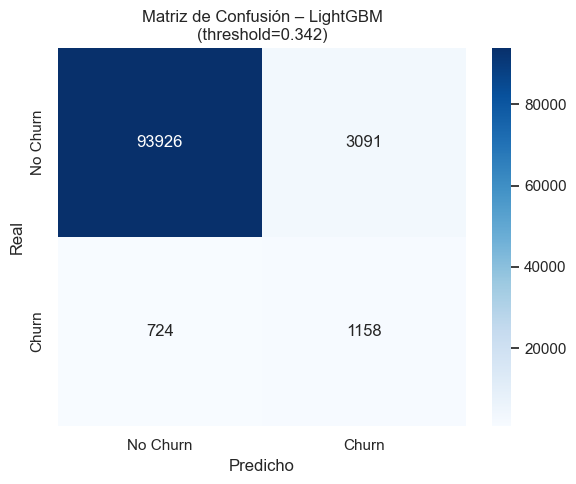

In [49]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_lgb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title(f'Matriz de Confusión – LightGBM\n(threshold={best_threshold:.3f})')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.show()

---
## 8. Mejoras del modelo y consideraciones de producción

### 8.1 ¿Qué haría para mejorar la performance?

In [50]:
mejoras = """
MEJORAS TÉCNICAS:
─────────────────────────────────────────────────────
1. HYPERPARAMETER TUNING:
   - Usar Optuna o Bayesian Search para optimizar hiperparámetros
     de LightGBM directamente por ganancia de negocio.
   - Actualmente se usaron parámetros razonables pero sin búsqueda exhaustiva.

2. FEATURES TEMPORALES (si hubiera más historia):
   - Tendencia de ARPU: ¿creció o cayó en los últimos 3 meses?
   - Días sin recarga: indicador temprano de churn.
   - Variación en minutos de uso mes a mes (delta).
   - Estas features son más predictivas que los valores absolutos.

3. ENSEMBLE / STACKING:
   - Combinar LightGBM + LogReg con pesos aprendidos.
   - En problemas de churn, el ensemble suele mejorar 1-2 puntos de AUC.

4. MEJOR MANEJO DEL DESBALANCE:
   - Probar SMOTE o undersampling controlado para balancear clases.
   - Calibrar probabilidades con Platt scaling o isotonic regression.

5. VALIDACIÓN CRUZADA TEMPORAL:
   - Usar Walk-Forward Validation en lugar de un único split temporal.
   - Evaluar estabilidad del modelo mes a mes.

INFORMACIÓN ADICIONAL QUE AYUDARÍA:
─────────────────────────────────────────────────────
- Historial de >3 meses para detectar tendencias de uso.
- Tipo de plan (prepago/pospago/híbrido): muy predictivo del churn.
- Quejas o interacciones con servicio al cliente.
- Cobertura de red en la zona del cliente.
- Datos de competidores (ofertas disponibles en la zona).
- Fecha de activación del número (antigüedad en la red).

PARA PRODUCCIÓN EN EL CORTO PLAZO:
─────────────────────────────────────────────────────
- Simplificaría a un modelo LightGBM con las top 20 features.
- Automatizaría el pipeline: ingesta → feature engineering → scoring.
- Generaría un archivo .csv con el ranking de clientes cada fin de mes.
- Monitorearía el drift de datos (PSI) y el AUC mensualmente.
- Reentrenamiento automático si el AUC cae >2 puntos.
"""
print(mejoras)


MEJORAS TÉCNICAS:
─────────────────────────────────────────────────────
1. HYPERPARAMETER TUNING:
   - Usar Optuna o Bayesian Search para optimizar hiperparámetros
     de LightGBM directamente por ganancia de negocio.
   - Actualmente se usaron parámetros razonables pero sin búsqueda exhaustiva.

2. FEATURES TEMPORALES (si hubiera más historia):
   - Tendencia de ARPU: ¿creció o cayó en los últimos 3 meses?
   - Días sin recarga: indicador temprano de churn.
   - Variación en minutos de uso mes a mes (delta).
   - Estas features son más predictivas que los valores absolutos.

3. ENSEMBLE / STACKING:
   - Combinar LightGBM + LogReg con pesos aprendidos.
   - En problemas de churn, el ensemble suele mejorar 1-2 puntos de AUC.

4. MEJOR MANEJO DEL DESBALANCE:
   - Probar SMOTE o undersampling controlado para balancear clases.
   - Calibrar probabilidades con Platt scaling o isotonic regression.

5. VALIDACIÓN CRUZADA TEMPORAL:
   - Usar Walk-Forward Validation en lugar de un único split

## 9. Output final: Lista de clientes prioritarios

In [51]:
# Exportar top 2000 para el equipo comercial
output_cols = ['rank', 'mobile_number', 'churn_proba', 'valor_esperado', 'arpu', 'churn']
top2000_export = top2000[output_cols].copy()
top2000_export.columns = ['rank', 'mobile_number', 'prob_churn', 'valor_esperado_CLP', 'arpu', 'churn_real']
top2000_export.to_csv('../notebooks/top2000_clientes_agosto2014.csv', index=False)

print('Archivo exportado: top2000_clientes_agosto2014.csv')
print()
print('Muestra del output:')
print(top2000_export.head(10).to_string(index=False))

Archivo exportado: top2000_clientes_agosto2014.csv

Muestra del output:
 rank  mobile_number  prob_churn  valor_esperado_CLP    arpu  churn_real
    1     7001905007      0.3418           1025.4085  0.0000           1
    2     7001225755      0.3418           1025.4085  0.0000           0
    3     7000361561      0.3418           1025.4085  0.0000           1
    4     7001858654      0.3418           1025.4085  0.0000           0
    5     7000850336      0.3418           1025.4085  0.0000           0
    6     7002289648      0.3418           1025.4085  0.0000           0
    7     7000759454      0.3418           1025.4085  0.0000           0
    8     7001006187      0.3418           1025.4085  0.0000           0
    9     7002233505      0.3418           1025.4085 -5.0000           0
   10     7000087599      0.3418           1025.4085  0.0000           0


In [52]:
print('='*60)
print('RESUMEN EJECUTIVO – MODELO DE CHURN ENTEL')
print('='*60)
print(f'Modelo final:          LightGBM')
print(f'AUC-ROC (test):        {results["LightGBM"]["auc"]:.4f}')
print(f'Avg Precision (test):  {results["LightGBM"]["ap"]:.4f}')
print()
print(f'Campaña – Agosto 2014:')
print(f'  Clientes contactados:    {BUDGET_CONTACTS:,}')
print(f'  Churners identificados:  {g["true_positives"]:,}')
print(f'  Precisión top 2.000:     {g["precision_top_n"]*100:.1f}%')
print(f'  Retenciones esperadas:   {g["true_positives"] * RETENTION_RATE:.1f}')
print(f'  Costo campaña:           ${g["costos_CLP"]:,.0f} CLP')
print(f'  Ingresos recuperados:    ${g["ingresos_CLP"]:,.0f} CLP')
print(f'  Ganancia neta:           ${g["ganancia_neta_CLP"]:,.0f} CLP')
print(f'  ROI:                     {g["ROI"]:.1f}%')
print()
print(f'  vs Baseline aleatorio:   ${baseline["ganancia_neta_CLP"]:,.0f} CLP')
print(f'  Mejora sobre baseline:   ${g["ganancia_neta_CLP"] - baseline["ganancia_neta_CLP"]:,.0f} CLP')
print('='*60)

RESUMEN EJECUTIVO – MODELO DE CHURN ENTEL
Modelo final:          LightGBM
AUC-ROC (test):        0.8526
Avg Precision (test):  0.1970

Campaña – Agosto 2014:
  Clientes contactados:    2,000
  Churners identificados:  540
  Precisión top 2.000:     27.0%
  Retenciones esperadas:   54.0
  Costo campaña:           $2,000,000 CLP
  Ingresos recuperados:    $1,620,000 CLP
  Ganancia neta:           $-380,000 CLP
  ROI:                     -19.0%

  vs Baseline aleatorio:   $-1,885,823 CLP
  Mejora sobre baseline:   $1,505,823 CLP
